In [1]:
# Cell 1
# =============================================================================
# Load Augmented DataFrames (Nodes A–H) & Base Label Encoder
# =============================================================================

import os
import joblib
import pandas as pd

NODES = ["A", "B", "C", "D", "E", "F", "G", "H"]
AUG_DIR = "dataset/normalized/augmented"
MODEL_DIR = "models"

aug_train = {}
aug_test = {}

# Load precomputed node-level augmented datasets
for node in NODES:
    aug_train[node] = joblib.load(os.path.join(AUG_DIR, f"Node_{node}_aug_train.pkl"))
    aug_test[node]  = joblib.load(os.path.join(AUG_DIR, f"Node_{node}_aug_test.pkl"))

# Load baseline label encoder
le = joblib.load(os.path.join(MODEL_DIR, "label_encoder.joblib"))

print(f"Loaded augmented node datasets from: '{AUG_DIR}'")
print(f"Baseline classes: {le.classes_}")
print(f"Example augmented columns (Node A): {aug_train['A'].columns.tolist()}")

Loaded augmented node datasets from: 'dataset/normalized/augmented'
Baseline classes: ['Backdoor' 'none' 'syn-flood']
Example augmented columns (Node A): ['shunt_voltage', 'bus_voltage_V', 'current_mA', 'power_mW', 'State', 'Attack', 'data_source', 'prob_Backdoor', 'prob_none', 'prob_syn-flood', 'agg_shunt_voltage', 'agg_bus_voltage_V', 'agg_current_mA', 'agg_power_mW', 'agg_prob_Backdoor', 'agg_prob_none', 'agg_prob_syn-flood', 'agg_weight_sum', 'agg_num_contributors']


In [2]:
# Cell 2
# =============================================================================
# Combine Augmented Data & Define Feature Sets
# =============================================================================

import os
import pandas as pd

# Concatenate all node-level DataFrames into unified train/test splits
df_train_aug = pd.concat([aug_train[node] for node in NODES], ignore_index=True)
df_test_aug  = pd.concat([aug_test[node]  for node in NODES], ignore_index=True)

# One-hot encode 'State' column
def add_state_dummies(df):
    df_out = df.copy()
    dummies = pd.get_dummies(df_out["State"], prefix="State", drop_first=False)
    for col in ["State_idle", "State_charging"]:
        if col not in dummies.columns:
            dummies[col] = 0
    return pd.concat([df_out, dummies[["State_idle", "State_charging"]]], axis=1)

df_train_aug = add_state_dummies(df_train_aug)
df_test_aug  = add_state_dummies(df_test_aug)

print("=== Combined Augmented Dataset Shapes ===")
print(f"Train Shape: {df_train_aug.shape}")
print(f"Test Shape:  {df_test_aug.shape}")

# Define feature sets
original_numeric = ["shunt_voltage", "bus_voltage_V", "current_mA", "power_mW"]
state_one_hot    = ["State_idle", "State_charging"]
own_prob_cols    = [f"prob_{cls_name}" for cls_name in le.classes_]
agg_numeric      = [f"agg_{f}" for f in original_numeric]
agg_prob_cols    = [f"agg_prob_{cls_name}" for cls_name in le.classes_]

# Model 1: Own hardware + Aggregated context (no own probabilities)
feature_cols_hw_plus_agg = original_numeric + state_one_hot + agg_numeric + agg_prob_cols

# Model 2: Full context (Own hardware + Own probabilities + Aggregated context)
feature_cols_full = original_numeric + state_one_hot + own_prob_cols + agg_numeric + agg_prob_cols

print(f"\nModel 1 Feature Count (Own HW + Agg Context): {len(feature_cols_hw_plus_agg)}")
print(f"Model 2 Feature Count (Full Context):         {len(feature_cols_full)}")

=== Combined Augmented Dataset Shapes ===
Train Shape: (245856, 21)
Test Shape:  (105456, 21)

Model 1 Feature Count (Own HW + Agg Context): 13
Model 2 Feature Count (Full Context):         16


In [3]:
# Cell 3
# =============================================================================
# Export Combined Augmented Datasets to CSV
# =============================================================================

import os

CSV_OUTPUT_DIR = "dataset/normalized/augmented_csv"
os.makedirs(CSV_OUTPUT_DIR, exist_ok=True)

train_csv_path = os.path.join(CSV_OUTPUT_DIR, "combined_augmented_train.csv")
test_csv_path  = os.path.join(CSV_OUTPUT_DIR, "combined_augmented_test.csv")

df_train_aug.to_csv(train_csv_path, index=False)
df_test_aug.to_csv(test_csv_path, index=False)

print("Saved combined augmented CSV files:")
print(f"  - Train: {train_csv_path} (Shape: {df_train_aug.shape})")
print(f"  - Test:  {test_csv_path}  (Shape: {df_test_aug.shape})")

Saved combined augmented CSV files:
  - Train: dataset/normalized/augmented_csv/combined_augmented_train.csv (Shape: (245856, 21))
  - Test:  dataset/normalized/augmented_csv/combined_augmented_test.csv  (Shape: (105456, 21))


In [4]:
# Cell 4
# =============================================================================
# Train & Save Model 1: Context-Aware RF (Own Hardware + Aggregated Reports)
# =============================================================================

import os
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

MODELS_DIR = "models"
os.makedirs(MODELS_DIR, exist_ok=True)

# Target encoding
le_context = LabelEncoder()
y_train_enc = le_context.fit_transform(df_train_aug["Attack"])
y_test_enc  = le_context.transform(df_test_aug["Attack"])

# Prepare features and scaling
numeric_cols_hw_agg = original_numeric + agg_numeric
scaler_hw_agg = StandardScaler()

X_train_hw_agg = df_train_aug[feature_cols_hw_plus_agg].copy()
X_test_hw_agg  = df_test_aug[feature_cols_hw_plus_agg].copy()

X_train_hw_agg[numeric_cols_hw_agg] = scaler_hw_agg.fit_transform(X_train_hw_agg[numeric_cols_hw_agg])
X_test_hw_agg[numeric_cols_hw_agg]  = scaler_hw_agg.transform(X_test_hw_agg[numeric_cols_hw_agg])

X_train_hw_agg_np = X_train_hw_agg.to_numpy()
X_test_hw_agg_np  = X_test_hw_agg.to_numpy()

# Train Random Forest with tuned hyperparameters
rf_hw_plus_agg = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)
rf_hw_plus_agg.fit(X_train_hw_agg_np, y_train_enc)

# Predictions & Metrics
train_pred_hw_agg = rf_hw_plus_agg.predict(X_train_hw_agg_np)
test_pred_hw_agg  = rf_hw_plus_agg.predict(X_test_hw_agg_np)

print("=== Model 1: Own HW + Aggregated Context ===")
print(f"OOB Score:      {rf_hw_plus_agg.oob_score_:.4f}")
print(f"Train Accuracy: {accuracy_score(y_train_enc, train_pred_hw_agg):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test_enc, test_pred_hw_agg):.4f}")

# Save Model 1 Artifacts
joblib.dump(rf_hw_plus_agg, os.path.join(MODELS_DIR, "rf_context_own_hw_plus_agg.joblib"))
joblib.dump(scaler_hw_agg, os.path.join(MODELS_DIR, "scaler_context_own_hw_plus_agg.joblib"))
joblib.dump(le_context, os.path.join(MODELS_DIR, "label_encoder_context.joblib"))

pd.DataFrame({"feature": feature_cols_hw_plus_agg}).to_csv(
    os.path.join(MODELS_DIR, "feature_list_own_hw_plus_agg.csv"),
    index=False
)

# Export predictions
df_pred_hw_agg = df_test_aug[["Attack"]].copy()
df_pred_hw_agg["prediction"] = le_context.inverse_transform(test_pred_hw_agg)

test_proba_hw_agg = rf_hw_plus_agg.predict_proba(X_test_hw_agg_np)
for idx, cls_idx in enumerate(rf_hw_plus_agg.classes_):
    cls_name = le_context.inverse_transform([cls_idx])[0]
    df_pred_hw_agg[f"prob_{cls_name}"] = test_proba_hw_agg[:, idx]

df_pred_hw_agg.to_csv(
    os.path.join(MODELS_DIR, "predictions_test_rf_context_own_hw_plus_agg.csv"),
    index=False
)
print("Model 1 artifacts and predictions saved successfully.")

=== Model 1: Own HW + Aggregated Context ===
OOB Score:      0.9702
Train Accuracy: 1.0000
Test Accuracy:  0.9095
Model 1 artifacts and predictions saved successfully.


In [5]:
# Cell 5
# =============================================================================
# Train & Save Model 2: Full Context RF (Own HW + Own Probs + Agg Context)
# =============================================================================

import os
import joblib
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Prepare features and scaling for Full Context Model
numeric_cols_full = original_numeric + agg_numeric
scaler_full = StandardScaler()

X_train_full = df_train_aug[feature_cols_full].copy()
X_test_full  = df_test_aug[feature_cols_full].copy()

X_train_full[numeric_cols_full] = scaler_full.fit_transform(X_train_full[numeric_cols_full])
X_test_full[numeric_cols_full]  = scaler_full.transform(X_test_full[numeric_cols_full])

X_train_full_np = X_train_full.to_numpy()
X_test_full_np  = X_test_full.to_numpy()

# Train Random Forest with tuned hyperparameters
rf_context_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)
rf_context_full.fit(X_train_full_np, y_train_enc)

# Predictions & Metrics
train_pred_full = rf_context_full.predict(X_train_full_np)
test_pred_full  = rf_context_full.predict(X_test_full_np)

print("=== Model 2: Full Context RF (Own HW + Own Probs + Agg Context) ===")
print(f"OOB Score:      {rf_context_full.oob_score_:.4f}")
print(f"Train Accuracy: {accuracy_score(y_train_enc, train_pred_full):.4f}")
print(f"Test Accuracy:  {accuracy_score(y_test_enc, test_pred_full):.4f}")

# Save Model 2 Artifacts
joblib.dump(rf_context_full, os.path.join(MODELS_DIR, "rf_context_full.joblib"))
joblib.dump(scaler_full, os.path.join(MODELS_DIR, "scaler_context_full.joblib"))

pd.DataFrame({"feature": feature_cols_full}).to_csv(
    os.path.join(MODELS_DIR, "feature_list_context_full.csv"),
    index=False
)

# Export predictions
df_pred_full = df_test_aug[["Attack"]].copy()
df_pred_full["prediction"] = le_context.inverse_transform(test_pred_full)

test_proba_full = rf_context_full.predict_proba(X_test_full_np)
for idx, cls_idx in enumerate(rf_context_full.classes_):
    cls_name = le_context.inverse_transform([cls_idx])[0]
    df_pred_full[f"prob_{cls_name}"] = test_proba_full[:, idx]

df_pred_full.to_csv(
    os.path.join(MODELS_DIR, "predictions_test_rf_context_full.csv"),
    index=False
)
print("Model 2 artifacts and predictions saved successfully.")

=== Model 2: Full Context RF (Own HW + Own Probs + Agg Context) ===
OOB Score:      0.9999
Train Accuracy: 1.0000
Test Accuracy:  0.9234
Model 2 artifacts and predictions saved successfully.


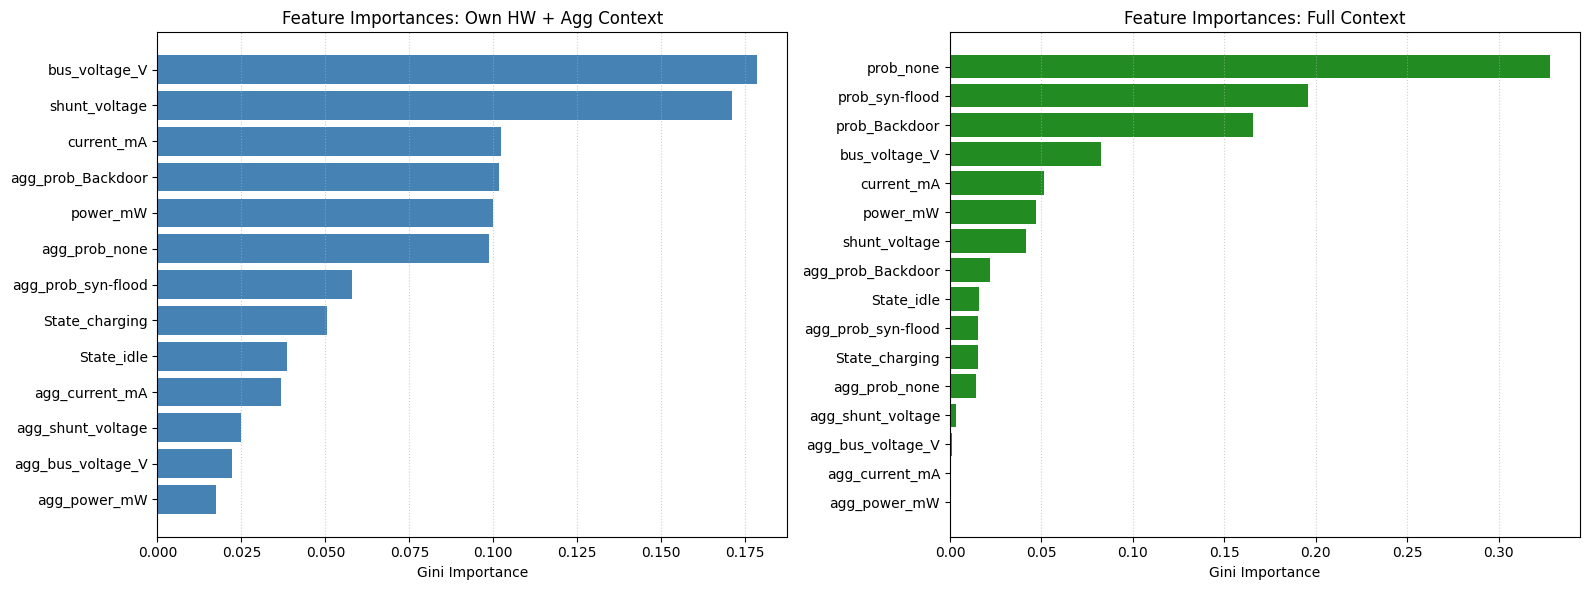

In [6]:
# Cell 6
# =============================================================================
# Plot Feature Importance Comparison
# =============================================================================

import os
import joblib
import matplotlib.pyplot as plt
import pandas as pd

MODELS_DIR = "models"

# Load trained models
rf_hw_agg = joblib.load(os.path.join(MODELS_DIR, "rf_context_own_hw_plus_agg.joblib"))
rf_full   = joblib.load(os.path.join(MODELS_DIR, "rf_context_full.joblib"))

feat_hw_agg = pd.read_csv(os.path.join(MODELS_DIR, "feature_list_own_hw_plus_agg.csv"))["feature"].tolist()
feat_full   = pd.read_csv(os.path.join(MODELS_DIR, "feature_list_context_full.csv"))["feature"].tolist()

# Create feature importance DataFrames
df_imp1 = pd.DataFrame({"Feature": feat_hw_agg, "Importance": rf_hw_agg.feature_importances_}).sort_values("Importance", ascending=True)
df_imp2 = pd.DataFrame({"Feature": feat_full,   "Importance": rf_full.feature_importances_}).sort_values("Importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(df_imp1["Feature"], df_imp1["Importance"], color="steelblue")
axes[0].set_title("Feature Importances: Own HW + Agg Context")
axes[0].set_xlabel("Gini Importance")
axes[0].grid(True, axis="x", linestyle=":", alpha=0.6)

axes[1].barh(df_imp2["Feature"], df_imp2["Importance"], color="forestgreen")
axes[1].set_title("Feature Importances: Full Context")
axes[1].set_xlabel("Gini Importance")
axes[1].grid(True, axis="x", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()